# Kinyarwanda Sentiment Classification — NLP Summative Project

**Task:** Text Classification (Sentiment Analysis) for an African Language
**Language:** Kinyarwanda
**Dataset:** [AfriSenti-SemEval](https://huggingface.co/datasets/HausaNLP/AfriSenti-Twitter) — human-labeled Kinyarwanda tweets (positive / negative / neutral), from the AfriSenti SemEval-2023 Task 12 shared task (Muhammad et al., 2023).

**Pipeline in this notebook:**
1. Load & explore the dataset
2. Preprocess text (cleaning, normalization)
3. Baseline model: TF-IDF + Logistic Regression
4. Experiment: TF-IDF + Linear SVM
5. Proposed model: fine-tune a pretrained Transformer (AfroXLMR) from Hugging Face
6. Experiment: compare against a second pretrained Transformer (AfriBERTa)
7. Evaluate all approaches (accuracy, precision, recall, macro-F1, confusion matrix)
8. Error analysis on misclassified examples
9. Save the best model for deployment (Streamlit app)

In [1]:
%%capture
!pip install -q datasets transformers evaluate scikit-learn accelerate

## 1. Load the Dataset

We use the Kinyarwanda subset of AfriSenti, loaded directly from the Hugging Face Hub. This is real, naturally-occurring, human-annotated Twitter data (not synthetic). The original `HausaNLP/AfriSenti-Twitter` repo ships a legacy loading script that newer versions of `datasets` no longer support, so we load from the script-free parquet mirror `mteb/AfriSentiClassification`, which contains the same official AfriSenti splits.

In [2]:
from datasets import load_dataset

# Kinyarwanda subset of AfriSenti (SemEval-2023 Task 12), via the script-free MTEB parquet mirror
# Original source: Muhammad et al. (2023), AfriSenti: A Twitter Sentiment Analysis
# Benchmark for African Languages. https://huggingface.co/datasets/mteb/AfriSentiClassification
ds = load_dataset("mteb/AfriSentiClassification", "kin")
print(ds)
print(ds["train"][0])

README.md:   0%|          | 0.00/12.9k [00:00<?, ?B/s]

kin/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  268kB            

kin/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

kin/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 66.2kB            

kin/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

kin/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3302 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/827 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1026 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3302
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 827
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1026
    })
})
{'text': '@user @user @user @user @user @user @user Hhhhhh ntabyihogoza, ubu x abo yishe bangana ik', 'label': 2}


In [3]:
# Official label mapping (from the original AfriSenti builder metadata on the Hub):
# ClassLabel(names=["positive", "negative", "neutral"]) -> 0=positive, 1=negative, 2=neutral
id2label = {0: "positive", 1: "negative", 2: "neutral"}
label2id = {v: k for k, v in id2label.items()}
print(id2label)

{0: 'positive', 1: 'negative', 2: 'neutral'}


## 2. Exploratory Data Analysis

Check class balance and text-length distribution before modeling. Unlike the Hausa subset of this same dataset (which we initially explored before switching to Kinyarwanda for this project — see project history), the Kinyarwanda **test** split is properly 3-way balanced across positive/negative/neutral, so we don't need any special-case handling of a missing class later on.


train (n=3302) label distribution:
label
negative    1257
neutral     1146
positive     899
Name: count, dtype: int64

validation (n=827) label distribution:
label
negative    315
neutral     287
positive    225
Name: count, dtype: int64

test (n=1026) label distribution:
label
negative    393
neutral     355
positive    278
Name: count, dtype: int64

Tweet length (words) stats:
count    3302.000000
mean       14.850394
std         5.742218
min         4.000000
25%        10.000000
50%        15.000000
75%        19.000000
max        69.000000
Name: n_words, dtype: float64


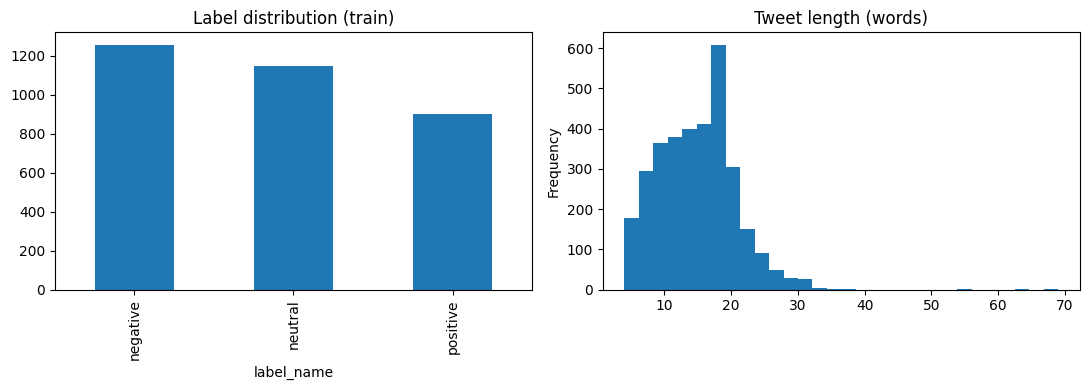

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"\n{split_name} (n={len(df)}) label distribution:")
    print(df["label"].map(id2label).value_counts())

train_df["label_name"] = train_df["label"].map(id2label)
train_df["n_words"] = train_df["text"].str.split().apply(len)
print("\nTweet length (words) stats:")
print(train_df["n_words"].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train_df["label_name"].value_counts().plot(kind="bar", ax=axes[0], title="Label distribution (train)")
train_df["n_words"].plot(kind="hist", bins=30, ax=axes[1], title="Tweet length (words)")
plt.tight_layout()
plt.show()

## 3. Preprocessing

These are tweets, so they contain `@mentions`, URLs, and emojis. We normalize mentions/URLs (they carry no sentiment signal and would otherwise inflate vocabulary size for the TF-IDF baseline) but keep emojis and punctuation, since these often carry real sentiment signal in tweets.

In [5]:
import re

def clean_tweet(text: str) -> str:
    text = re.sub(r"http\S+|www\.\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for split_df in (train_df, val_df, test_df):
    split_df["clean_text"] = split_df["text"].apply(clean_tweet)

print(train_df[["text", "clean_text"]].head(3).to_string())

                                                                                                text                                                                                         clean_text
0          @user @user @user @user @user @user @user Hhhhhh ntabyihogoza, ubu x abo yishe bangana ik   <USER> <USER> <USER> <USER> <USER> <USER> <USER> Hhhhhh ntabyihogoza, ubu x abo yishe bangana ik
1                             @user Amahano?! Ni impanuka, inkangu, inzara.... Muyite izina rikwiye.                            <USER> Amahano?! Ni impanuka, inkangu, inzara.... Muyite izina rikwiye.
2  Ese umuntu aguhaye miliyoni 7 zidorali ngo aryamane numugore wawe cg umukunzi wawe wabyemera🙄????  Ese umuntu aguhaye miliyoni 7 zidorali ngo aryamane numugore wawe cg umukunzi wawe wabyemera🙄????


## 4. Baseline Model: TF-IDF + Logistic Regression

A simple, fast, fully-interpretable baseline. This gives us a number the more complex Transformer models must beat to justify their extra cost.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

X_train, y_train = train_df["clean_text"], train_df["label"]
X_val, y_val = val_df["clean_text"], val_df["label"]
X_test, y_test = test_df["clean_text"], test_df["label"]

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

baseline_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_clf.fit(X_train_tfidf, y_train)

val_preds = baseline_clf.predict(X_val_tfidf)
acc = accuracy_score(y_val, val_preds)
p, r, f1, _ = precision_recall_fscore_support(y_val, val_preds, average="macro")
print(f"[TF-IDF + LogReg] val accuracy={acc:.4f} macro-P={p:.4f} macro-R={r:.4f} macro-F1={f1:.4f}")

[TF-IDF + LogReg] val accuracy=0.5816 macro-P=0.5841 macro-R=0.5837 macro-F1=0.5838


## 5. Experiment: TF-IDF + Linear SVM

Investigating whether a different classifier on the same features changes performance — part of the required baseline experimentation.

In [7]:
from sklearn.svm import LinearSVC

svm_clf = LinearSVC(class_weight="balanced")
svm_clf.fit(X_train_tfidf, y_train)

val_preds_svm = svm_clf.predict(X_val_tfidf)
acc_svm = accuracy_score(y_val, val_preds_svm)
p_svm, r_svm, f1_svm, _ = precision_recall_fscore_support(y_val, val_preds_svm, average="macro")
print(f"[TF-IDF + LinearSVC] val accuracy={acc_svm:.4f} macro-P={p_svm:.4f} macro-R={r_svm:.4f} macro-F1={f1_svm:.4f}")

# running experiment log — appended to as we try more approaches
results = [
    {"approach": "TF-IDF + Logistic Regression", "val_accuracy": acc, "val_macro_f1": f1},
    {"approach": "TF-IDF + Linear SVM", "val_accuracy": acc_svm, "val_macro_f1": f1_svm},
]
pd.DataFrame(results)

[TF-IDF + LinearSVC] val accuracy=0.5647 macro-P=0.5677 macro-R=0.5657 macro-F1=0.5666


,approach,val_accuracy,val_macro_f1
0,TF-IDF + Logistic Regression,0.581620,0.583845
1,TF-IDF + Linear SVM,0.564692,0.566628


## 6. Proposed Model: Fine-tuning AfroXLMR

**Model:** [`Davlan/afro-xlmr-base`](https://huggingface.co/Davlan/afro-xlmr-base) — an XLM-R checkpoint further pretrained by Alabi et al. (2022) on 17 African languages, **explicitly including Kinyarwanda as its own distinct language** (separate from Kirundi), giving it contextual embeddings that already understand Kinyarwanda morphology/vocabulary.

We add a classification head on top and fine-tune the whole model end-to-end on our labeled training set (standard Transformer fine-tuning, as covered in the course).

> **Note:** make sure the Colab runtime has a GPU (`Runtime > Change runtime type > T4 GPU`) before running the training cell below — fine-tuning on CPU will be very slow.

In [8]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
Tesla T4


In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "Davlan/afro-xlmr-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=64)

ds_tok = ds.map(tokenize_fn, batched=True)
ds_tok = ds_tok.rename_column("label", "labels")
ds_tok.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
print(ds_tok)

config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/398 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: Davlan/afro-xlmr-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/3302 [00:00<?, ? examples/s]

Map:   0%|          | 0/827 [00:00<?, ? examples/s]

Map:   0%|          | 0/1026 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 3302
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 827
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 1026
    })
})


In [10]:
from transformers import TrainingArguments, Trainer
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

training_args = TrainingArguments(
    output_dir="afroxlmr-kinyarwanda-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["validation"],
    compute_metrics=compute_metrics,
)

In [11]:
train_result = trainer.train()
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.824752,0.843669,0.627570,0.662269,0.617107,0.627479
2,0.755499,0.794842,0.651753,0.656296,0.654665,0.655188
3,0.657733,0.806431,0.654172,0.659971,0.654655,0.656773


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=621, training_loss=0.7833298131847535, metrics={'train_runtime': 295.2939, 'train_samples_per_second': 33.546, 'train_steps_per_second': 2.103, 'total_flos': 325800189501696.0, 'train_loss': 0.7833298131847535, 'epoch': 3.0})


### Capture validation metrics right away

We pull AfroXLMR's **validation** metrics from its training history immediately after training finishes — before running any evaluation on the test set below. (`Trainer.evaluate()` appends to the same `log_history` list, so capturing this now, rather than after a later test-set call, avoids silently picking up the wrong entry.)

In [12]:
val_log_entries = [h for h in trainer.state.log_history if "eval_accuracy" in h]
best_val_xlmr = val_log_entries[-1]
print("AfroXLMR validation metrics (best checkpoint):")
print({k: v for k, v in best_val_xlmr.items() if k.startswith("eval_")})

AfroXLMR validation metrics (best checkpoint):
{'eval_loss': 0.8064305782318115, 'eval_accuracy': 0.6541717049576784, 'eval_precision': 0.6599707467650916, 'eval_recall': 0.6546547941669892, 'eval_f1': 0.6567727016693818, 'eval_runtime': 2.8969, 'eval_samples_per_second': 285.473, 'eval_steps_per_second': 8.975}


## 7. Evaluate the Fine-tuned Model on the Test Set

Unlike the Hausa subset of this dataset, Kinyarwanda's test split is properly 3-way balanced, so these test metrics are directly trustworthy (no class-imbalance caveat needed here).

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.657733,0.780747,3,0.677388,0.682001,0.680054,0.680955


{'eval_loss': 0.7807468175888062, 'eval_accuracy': 0.6773879142300195, 'eval_precision': 0.6820005214289647, 'eval_recall': 0.6800540945589942, 'eval_f1': 0.680954763930626}


              precision    recall  f1-score   support

    positive       0.72      0.70      0.71       278
    negative       0.65      0.65      0.65       393
     neutral       0.67      0.69      0.68       355

    accuracy                           0.68      1026
   macro avg       0.68      0.68      0.68      1026
weighted avg       0.68      0.68      0.68      1026



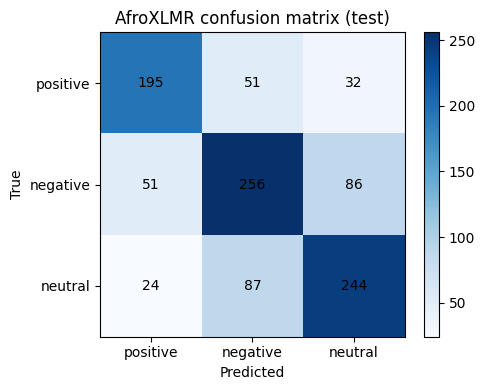

In [13]:
test_metrics = trainer.evaluate(ds_tok["test"])
print(test_metrics)

test_preds_logits = trainer.predict(ds_tok["test"]).predictions
test_preds = np.argmax(test_preds_logits, axis=-1)

print(classification_report(y_test, test_preds, target_names=[id2label[i] for i in range(3)]))

cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels([id2label[i] for i in range(3)])
ax.set_yticks(range(3)); ax.set_yticklabels([id2label[i] for i in range(3)])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("AfroXLMR confusion matrix (test)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 8. Experiment Comparison

All approaches evaluated on the same validation split for a fair comparison, with the test-set result for AfroXLMR shown for reference too.

In [14]:
results.append({
    "approach": "Fine-tuned AfroXLMR",
    "val_accuracy": best_val_xlmr["eval_accuracy"],
    "val_macro_f1": best_val_xlmr["eval_f1"],
})
comparison_df = pd.DataFrame(results)
print("Validation-set comparison (fair, apples-to-apples):")
display(comparison_df)

print("\nAfroXLMR on the TEST set:")
print({k: v for k, v in test_metrics.items() if k.startswith("eval_")})

Validation-set comparison (fair, apples-to-apples):


,approach,val_accuracy,val_macro_f1
0,TF-IDF + Logistic Regression,0.581620,0.583845
1,TF-IDF + Linear SVM,0.564692,0.566628
2,Fine-tuned AfroXLMR,0.654172,0.656773



AfroXLMR on the TEST set:
{'eval_loss': 0.7807468175888062, 'eval_accuracy': 0.6773879142300195, 'eval_precision': 0.6820005214289647, 'eval_recall': 0.6800540945589942, 'eval_f1': 0.680954763930626}


## 9. Error Analysis

Look at misclassified test examples to understand *why* the model fails — not just the aggregate score.

In [15]:
error_df = test_df.copy()
error_df["pred"] = test_preds
error_df["pred_name"] = error_df["pred"].map(id2label)
error_df["label_name"] = error_df["label"].map(id2label)
errors = error_df[error_df["label"] != error_df["pred"]]

print(f"Total errors: {len(errors)} / {len(error_df)} ({len(errors)/len(error_df):.1%})")
print("\nMost confused label pairs (true -> predicted):")
print(errors.groupby(["label_name", "pred_name"]).size().sort_values(ascending=False).head(10))

print("\nSample misclassified examples:")
for _, row in errors.sample(min(8, len(errors)), random_state=42).iterrows():
    print(f"- true={row['label_name']:8s} pred={row['pred_name']:8s} | {row['text']}")

Total errors: 331 / 1026 (32.3%)

Most confused label pairs (true -> predicted):
label_name  pred_name
neutral     negative     87
negative    neutral      86
            positive     51
positive    negative     51
            neutral      32
neutral     positive     24
dtype: int64

Sample misclassified examples:
- true=negative pred=neutral  | @user Ntanubwo izongera gukora! Bayikuye Ku mugati Kera yaranabitangaje
- true=neutral  pred=negative | @user Itangazamakuru urisuzumira kuri twitter se? Iyi ni page yanjye bwite sinzi niba hari uguhatira kuyirebaho.
- true=positive pred=neutral  | @user Uyu musore niyo ntwari yonyine ikiriho mu zo nzi😂
- true=neutral  pred=positive | Arata umwanya, kuko ibye birazwi ku buryo buhagije. Amateka ye mabi n'uyo yabloka abantu bose ntiyasibangana. https://t.co/THzOZgvxd2
- true=neutral  pred=negative | @user Naho se iya bakobwa nukurya amafaranga yose ari ku isi kugeza shaze?
- true=negative pred=positive | Impungenge zishire Ubu wakoresha uruga O’G

## 10. Experiment: Comparing a Second Pretrained Transformer (AfriBERTa)

**Why this experiment:** AfroXLMR (used above) is a general-purpose multilingual model (XLM-R) that was *adapted* to African languages via continued pretraining (Alabi et al., 2022), and its training data explicitly includes **clean, standalone Kinyarwanda**. [AfriBERTa](https://huggingface.co/castorini/afriberta_large) (Ogueji et al., 2021) takes a different approach: it is pretrained **from scratch** on a small corpus of 11 African languages — but for Kinyarwanda specifically, its training data is **"Gahuza," a mixed Kinyarwanda/Kirundi corpus**, not pure Kinyarwanda (confirmed directly from the model's official card on the Hugging Face Hub).

This sets up a genuine, verifiable research question: does exposure to *clean* Kinyarwanda (AfroXLMR) outperform exposure to *code-mixed* Kinyarwanda/Kirundi (AfriBERTa) on a pure-Kinyarwanda downstream task? We fine-tune it identically (same hyperparameters, same preprocessing) so the comparison isolates the effect of the pretrained checkpoint.

In [16]:
from transformers import AutoTokenizer as AutoTokenizer2, AutoModelForSequenceClassification as AutoModel2

AFRIBERTA_MODEL_NAME = "castorini/afriberta_large"

afriberta_tokenizer = AutoTokenizer2.from_pretrained(AFRIBERTA_MODEL_NAME)
afriberta_model = AutoModel2.from_pretrained(
    AFRIBERTA_MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
)

def afriberta_tokenize_fn(batch):
    return afriberta_tokenizer(batch["text"], truncation=True, padding="max_length", max_length=64)

ds_tok_afriberta = ds.map(afriberta_tokenize_fn, batched=True)
ds_tok_afriberta = ds_tok_afriberta.rename_column("label", "labels")
ds_tok_afriberta.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
print(ds_tok_afriberta)

config.json:   0%|          | 0.00/731 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/257 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 1.55MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  503MB            

model.safetensors: downloading bytes:           |  0.00B            

Map:   0%|          | 0/827 [00:00<?, ? examples/s]

Map:   0%|          | 0/1026 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 3302
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 827
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 1026
    })
})


In [17]:
afriberta_training_args = TrainingArguments(
    output_dir="afriberta-kinyarwanda-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
)

afriberta_trainer = Trainer(
    model=afriberta_model,
    args=afriberta_training_args,
    train_dataset=ds_tok_afriberta["train"],
    eval_dataset=ds_tok_afriberta["validation"],
    compute_metrics=compute_metrics,
)

afriberta_train_result = afriberta_trainer.train()
print(afriberta_train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.861049,0.886028,0.598549,0.630000,0.582470,0.588227
2,0.715933,0.865700,0.627570,0.630416,0.625882,0.627820
3,0.531440,0.964319,0.634825,0.641045,0.630848,0.634608


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=621, training_loss=0.7323843330960726, metrics={'train_runtime': 163.1296, 'train_samples_per_second': 60.725, 'train_steps_per_second': 3.807, 'total_flos': 271877020197120.0, 'train_loss': 0.7323843330960726, 'epoch': 3.0})


In [18]:
afriberta_val_log = [h for h in afriberta_trainer.state.log_history if "eval_accuracy" in h]
best_val_afriberta = afriberta_val_log[-1]
print("AfriBERTa validation metrics (best checkpoint):")
print({k: v for k, v in best_val_afriberta.items() if k.startswith("eval_")})

afriberta_test_metrics = afriberta_trainer.evaluate(ds_tok_afriberta["test"])
print("\nAfriBERTa TEST metrics:")
print({k: v for k, v in afriberta_test_metrics.items() if k.startswith("eval_")})

results.append({
    "approach": "Fine-tuned AfriBERTa",
    "val_accuracy": best_val_afriberta["eval_accuracy"],
    "val_macro_f1": best_val_afriberta["eval_f1"],
})
comparison_df = pd.DataFrame(results)
print("\nUpdated validation-set comparison:")
display(comparison_df)

AfriBERTa validation metrics (best checkpoint):
{'eval_loss': 0.9643185138702393, 'eval_accuracy': 0.6348246674727932, 'eval_precision': 0.6410449032335469, 'eval_recall': 0.6308478513356562, 'eval_f1': 0.6346083648382709, 'eval_runtime': 2.5669, 'eval_samples_per_second': 322.183, 'eval_steps_per_second': 10.129}


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.531440,0.907885,3,0.635478,0.638127,0.637478,0.637768



AfriBERTa TEST metrics:
{'eval_loss': 0.9078848361968994, 'eval_accuracy': 0.6354775828460039, 'eval_precision': 0.6381274409745595, 'eval_recall': 0.6374778297993795, 'eval_f1': 0.6377679361156242}

Updated validation-set comparison:


,approach,val_accuracy,val_macro_f1
0,TF-IDF + Logistic Regression,0.581620,0.583845
1,TF-IDF + Linear SVM,0.564692,0.566628
2,Fine-tuned AfroXLMR,0.654172,0.656773
3,Fine-tuned AfriBERTa,0.634825,0.634608


**Interpreting this experiment:** compare AfriBERTa's validation macro-F1 to AfroXLMR's above.

- If AfroXLMR **beats** AfriBERTa: it supports the hypothesis that clean, language-specific pretraining data (AfroXLMR's standalone Kinyarwanda) transfers better than code-mixed data (AfriBERTa's Gahuza) for a pure-Kinyarwanda task.
- If AfriBERTa **matches or beats** AfroXLMR despite the code-mixed pretraining: it suggests the linguistic overlap between Kinyarwanda and Kirundi (both Bantu languages, mutually intelligible to a degree) is large enough that Gahuza exposure transfers almost as well as pure Kinyarwanda — a genuinely interesting finding about cross-lingual transfer between closely related languages.

Write down the actual numbers you get here and the explanation that matches them in your report's Experiments & Discussion section.

## 11. Save Model for Deployment

Push to the Hugging Face Hub (recommended — the deployed app will load it directly from there) using a token stored as a Colab secret (icon in the sidebar) — never paste tokens directly into notebook cells or chat.

In [20]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get("HF_TOKEN"))

HF_USERNAME = "Iyamurinze"

# AfroXLMR
XLMR_REPO = f"{HF_USERNAME}/afroxlmr-kinyarwanda-sentiment"
trainer.push_to_hub(XLMR_REPO)
tokenizer.push_to_hub(XLMR_REPO)
print(f"Pushed to https://huggingface.co/{XLMR_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/1.85k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp6lr849sv/tokenizer.json: 100%|##########| 17.1MB / 17.1MB            

Validating                    :           |   0%            

Pushed to https://huggingface.co/Iyamurinze/afroxlmr-kinyarwanda-sentiment
